In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the data from folder

In [2]:
# import tkinter as tk
# from tkinter import filedialog
# # Hide the main tkinter window
# root = tk.Tk()
# root.withdraw()

# # Open a dialog to select the session folder
# base_folder = filedialog.askdirectory(title="Select session folder", initialdir=r"/Users/shunli/Downloads/sabalab/forPaolo")
# # Extract the session_id from the selected folder name
# session_id = os.path.basename(base_folder)
# print(f"Selected session_id: {session_id}")
# print(f"Base folder: {base_folder}")

In [3]:
mat_path = rf"/Users/shunli/Projects/pyNeuroDAP/Data/20250622 Data (InsCtx Chronic)/20250616_M346_4W50_g0_ccm.mat"
session_id = os.path.basename(mat_path)
print(f"Selected session_id: {session_id}")
session_mat = sio.loadmat(mat_path)

# Extract mat file data
params = ndap.convert_params_from_mat(session_mat)
spikes = ndap.convert_spikes_from_mat(params, user='shijia')
behaviors = ndap.convert_behaviors_from_mat(session_mat, user='shijia')

Selected session_id: 20250616_M346_4W50_g0_ccm.mat


In [4]:
# Get spikes for each condition
from tqdm import tqdm

# Define parameters common to all sessions
bin_size = 25           # in ms
time_range = (-1,3)     # in sec
xaxis = ndap.get_time_axis(time_range, bin_size_ms=bin_size)

print('Aligning spikes to behavior events...')
aligned_trial_start = {}
for cond, times in tqdm(behaviors['trial_start_times'].items(), desc="Aligning to trial starts", leave=True):
    aligned_trial_start[cond] = ndap.get_spikes(spikes, np.array(times), time_range, bin_size_ms=bin_size, same_system=False, params=params)
print('Finished: get spikes for trial starts')

Aligning spikes to behavior events...


Aligning to trial starts: 100%|██████████| 3/3 [00:01<00:00,  1.86it/s]

Finished: get spikes for trial starts


(174, 160)


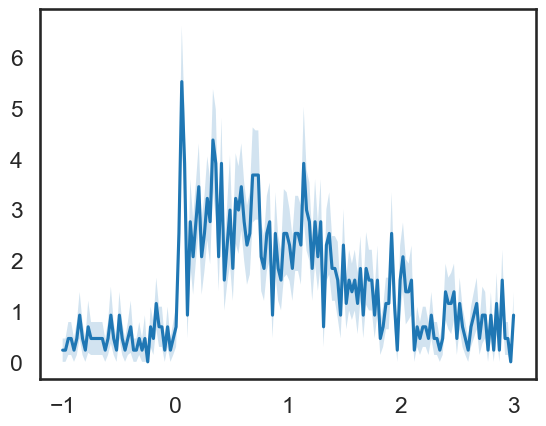

In [5]:
# Plot sample spike PSTH
unit_id = 544
rates, plot_xaxis = ndap.get_window(aligned_trial_start['reward_control']['rate'], onset_time=0, window_ms=(-1000,3000), xaxis=xaxis, return_xaxis=True)
print(rates[unit_id].shape)
ndap.plot_sem(rates[unit_id],x=plot_xaxis)
plt.show()

In [6]:
# Store meta data

trial_conditions = ['reward_control', 'omission_control', 'miss_control']

metadata = {
    'session_name': session_id,
    'subject_id': 'SL326', # to be change later
    'recording_location': 'InsCtx',
    'laser_onset': 0,
    'laser_duration': 0,
    'trial_range': 'all',
    'bin_size': bin_size,
    'time_range': str(time_range),
    'trial_conditions': trial_conditions
}

## 2. rSLDS

### 2.1 Prepare rSLDS data

Combining 1 conditions: ['reward_control']
Combining 1 conditions: ['omission_control']


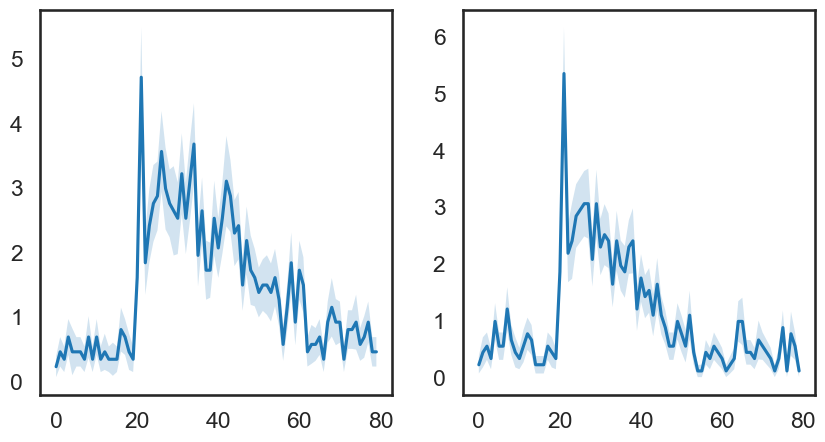

[prepare_rslds_data] Data z-scored


In [7]:
# Prepare data for rSLDS
type1_data = ndap.downsample(ndap.combine_rates(aligned_trial_start, key="reward"), target_bin_size_ms=50, original_bin_size_ms=25)
type2_data = ndap.downsample(ndap.combine_rates(aligned_trial_start, key="omission"), target_bin_size_ms=50, original_bin_size_ms=25)
type1_data = np.asarray(type1_data)
type2_data = np.asarray(type2_data)

# Plot the data
unit_id = 544
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ndap.plot_sem(type1_data[unit_id], ax=axes[0])
ndap.plot_sem(type2_data[unit_id], ax=axes[1])
plt.show()

# Concatenate datasets by trials
combined_data = np.concatenate([type1_data, type2_data], axis=1)
type1_label = np.ones(type1_data.shape[1], dtype=bool)
type2_label = np.zeros(type2_data.shape[1], dtype=bool)
trial_types = np.r_[type1_label, type2_label]

# Prepare data for plotting
rslds_data, inputs = ndap.prepare_rslds_data(combined_data, trial_types=trial_types)
idx1 = np.where(trial_types)[0]
idx2 = np.where(~trial_types)[0]
type1_tuple = ([rslds_data[i] for i in idx1], [inputs[i] for i in idx1])   # (Y1, U1)
type2_tuple = ([rslds_data[i] for i in idx2], [inputs[i] for i in idx2])   # (Y2, U2)

### 2.2. Fit a rSLDS model

In [8]:
# Set rSLDS parameters
n_states = 4         # Number of discrete states (change as appropriate)
n_latent_dims = 2    # Number of latent dimensions (for visualization)
num_iters = 50      # Number of EM iterations

# Fit the rSLDS model
rslds, posterior, elbos = ndap.fit_rslds_model((rslds_data, inputs), n_states=n_states, n_latent_dims=n_latent_dims, num_iters=num_iters)
save_path = ndap.save_rslds_model(rslds, posterior, (rslds_data, inputs), "rslds_-1to3.joblib", 
                                elbos=elbos, time_range=time_range, bin_size=bin_size)

Initializing model...
Fitting rSLDS with laplace_em method...


ELBO: -30897532.5: 100%|██████████| 50/50 [10:02<00:00, 12.05s/it]


Fitting completed. Final ELBO: -30897532.46


### 2.3. Plot model

In [14]:
# Load model
# if 'save_path' not in locals():
#     save_path = "Results/rslds_models/rslds-20250829/rslds_-1to5.joblib"
#     print(f"Load rSLDS model from: {save_path}")

save_path = "Results/rslds_models/rslds-20250830/rslds_-1to3.joblib"
B = ndap.load_rslds_model(save_path)

model = B["objects"]["model"]
posterior = B["objects"]["posterior"]
Y = B["data"]["Y_list"]
U = B["data"]["U_list"]
x = B["posterior"]["x_list"][0]
z = B["posterior"]["z_list"][0]
elbos = B["posterior"]["elbos"]
time_range = B["data"]["time_range"]
bin_size = B["data"]["bin_size"]

# Build type1_tuple and type2_tuple from Y and U
U_arr = np.asarray(U)
idx1 = np.unique(np.where((U_arr == np.array([0., 1.])).all(axis=1))[0])
idx2 = np.unique(np.where((U_arr == np.array([1., 0.])).all(axis=1))[0])
type1_tuple = ([Y[i] for i in idx1], [U[i] for i in idx1])
type2_tuple = ([Y[i] for i in idx2], [U[i] for i in idx2])

In [15]:
# Optional: save adi
# save_path = ndap.save_rslds_model(model, posterior, (Y, U), "rslds_-1to5.joblib", 
#                                 elbos=elbos, time_range=(-1,5), bin_size=50)

Key time (in sec): [0, 1, 3]
time_range: (-1, 3) sec, bin_size: 25 ms


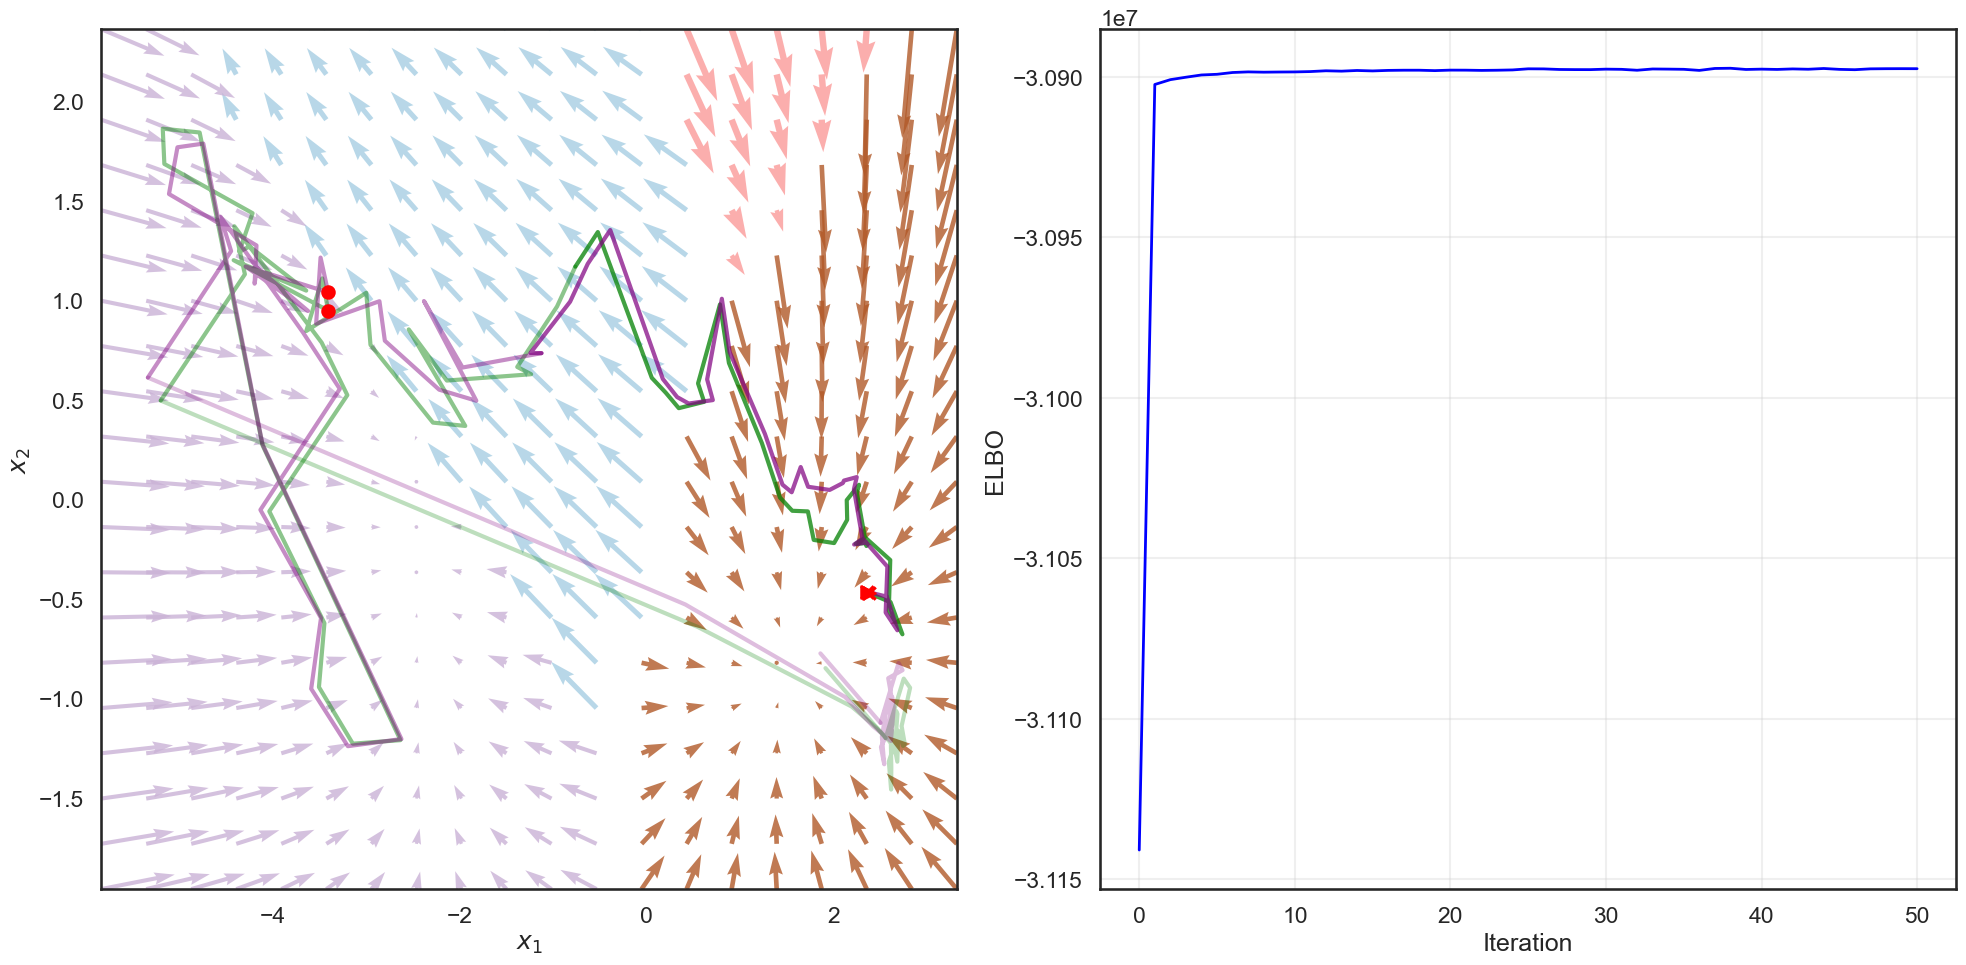

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
key_time = [0, 1, time_range[1]]
print(f"Key time (in sec): {key_time}")
print(f"time_range: {time_range} sec, bin_size: {bin_size} ms")
# Select trial indices
t1_idx = None
t2_idx = None

# Vector field / most-likely dynamics
ndap.plot_rslds_trajectory(model, posterior, type1_tuple, ax=axes[0], trial_idx=t1_idx,
                           color="green", key_time=key_time, time_range=time_range, bin_size=bin_size)
ndap.plot_rslds_trajectory(model, posterior, type2_tuple, ax=axes[0], trial_idx=t2_idx,
                           color="purple", key_time=key_time, time_range=time_range, bin_size=bin_size)
ndap.plot_rslds_dynamics(model, ax=axes[0])

# ELBO curve saved in the bundle
ndap.plot_rslds_elbo(elbos, ax=axes[1])

plt.tight_layout()
plt.show()

In [17]:
# # Observations colored by inferred states for matching trials
# ndap.plot_rslds_observations(model, posterior, type1_tuple, ax=axes[1, 0], trial_idx=t1_idx,
#                              color="green", key_time=key_time, time_range=time_range, bin_size=bin_size)
# ndap.plot_rslds_observations(model, posterior, type2_tuple, ax=axes[1, 0], trial_idx=t2_idx,
#                              color="purple", key_time=key_time, time_range=time_range, bin_size=bin_size)